In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("student_attendance_prediction_dataset.csv")

df.head()

,Student_ID,Age,Course,Semester,Total_Classes,Classes_Attended,Previous_Month_Attendance,Assignment_Submission,Internal_Marks,Practical_Attendance,Medical_Leave,Extracurricular_Hours,Commute_Time_Min,Most_Absent_Day,Future_Attendance_Percentage,Risk_Level
0,STU1001,21,IT,4,100,78,97.2,58.0,68.3,83.9,5,1.9,72,Tuesday,65.0,Medium
1,STU1002,22,AI&DS,5,55,36,85.7,87.9,87.4,47.8,3,2.5,97,Monday,64.4,Medium
2,STU1003,19,AI&DS,3,55,30,67.1,60.1,64.9,49.0,2,7.6,48,Thursday,55.9,High
3,STU1004,21,ECE,3,52,29,67.3,90.2,38.4,67.2,3,2.6,38,Saturday,55.1,High
4,STU1005,21,IT,3,56,41,84.1,68.3,86.1,61.2,2,0.2,81,Saturday,64.5,Medium


In [ ]:
df.shape

(500, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    500 non-null    object 
 1   Age                           500 non-null    int64  
 2   Course                        500 non-null    object 
 3   Semester                      500 non-null    int64  
 4   Total_Classes                 500 non-null    int64  
 5   Classes_Attended              500 non-null    int64  
 6   Previous_Month_Attendance     500 non-null    float64
 7   Assignment_Submission         500 non-null    float64
 8   Internal_Marks                500 non-null    float64
 9   Practical_Attendance          500 non-null    float64
 10  Medical_Leave                 500 non-null    int64  
 11  Extracurricular_Hours         500 non-null    float64
 12  Commute_Time_Min              500 non-null    int64  
 13  Most_

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Course,0
Semester,0
Total_Classes,0
Classes_Attended,0
Previous_Month_Attendance,0
Assignment_Submission,0
Internal_Marks,0
Practical_Attendance,0


In [ ]:
df.duplicated().sum()

np.int64(0)

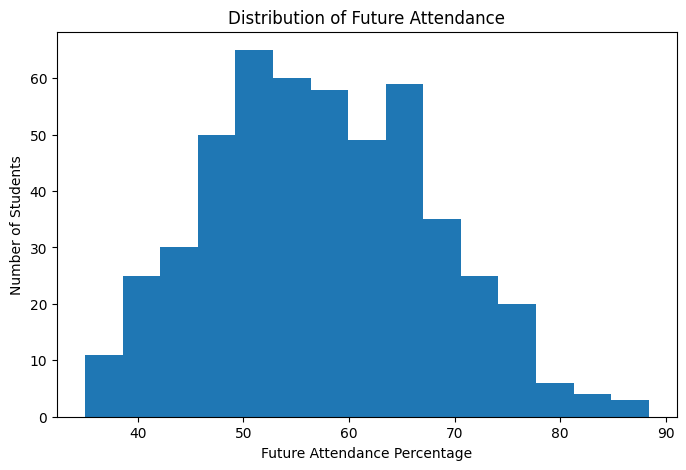

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Future_Attendance_Percentage"], bins=15)

plt.xlabel("Future Attendance Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Future Attendance")

plt.show()

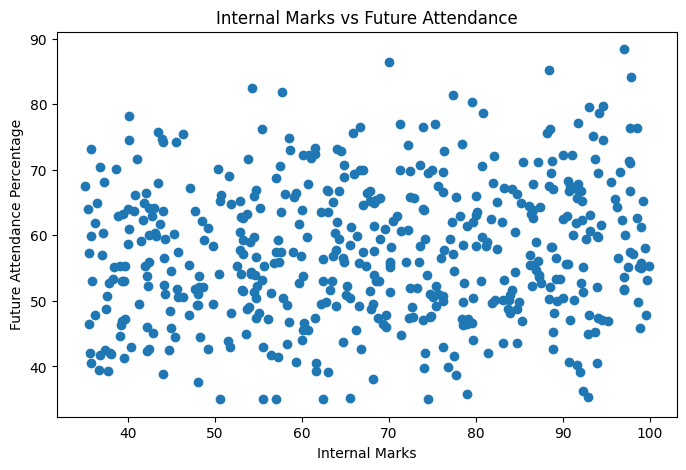

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Internal_Marks"],
    df["Future_Attendance_Percentage"]
)

plt.xlabel("Internal Marks")
plt.ylabel("Future Attendance Percentage")
plt.title("Internal Marks vs Future Attendance")

plt.show()

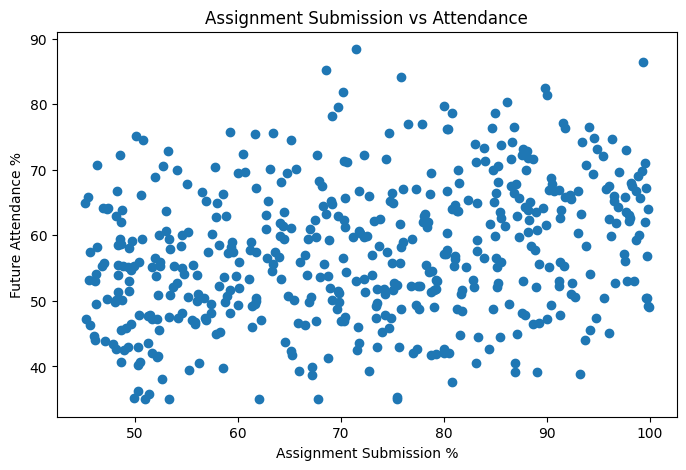

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Assignment_Submission"],
    df["Future_Attendance_Percentage"]
)

plt.xlabel("Assignment Submission %")
plt.ylabel("Future Attendance %")
plt.title("Assignment Submission vs Attendance")

plt.show()

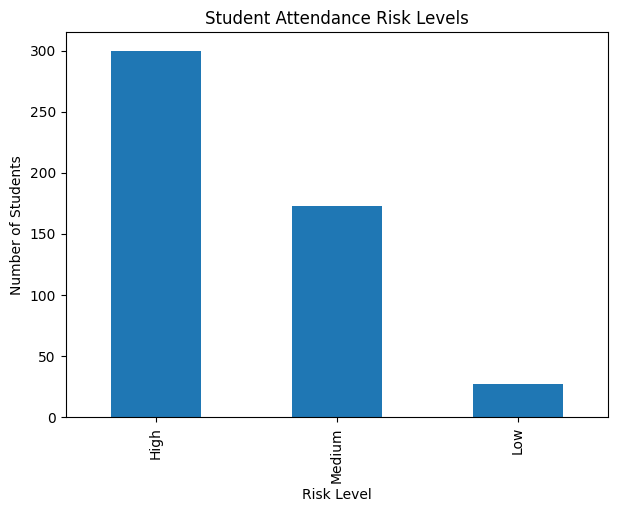

In [ ]:
df["Risk_Level"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.title("Student Attendance Risk Levels")

plt.show()

In [ ]:
y = df["Future_Attendance_Percentage"]

In [ ]:
X = df[
    [
        "Age",
        "Semester",
        "Total_Classes",
        "Classes_Attended",
        "Previous_Month_Attendance",
        "Assignment_Submission",
        "Internal_Marks",
        "Practical_Attendance",
        "Medical_Leave",
        "Extracurricular_Hours",
        "Commute_Time_Min"
    ]
]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[48.647 62.668 44.027 45.988 68.696 69.57  52.899 67.679 48.918 58.144]


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

MAE: 4.5184199999999946
MSE: 33.265607999999965
R2 Score: 0.6866837390532867


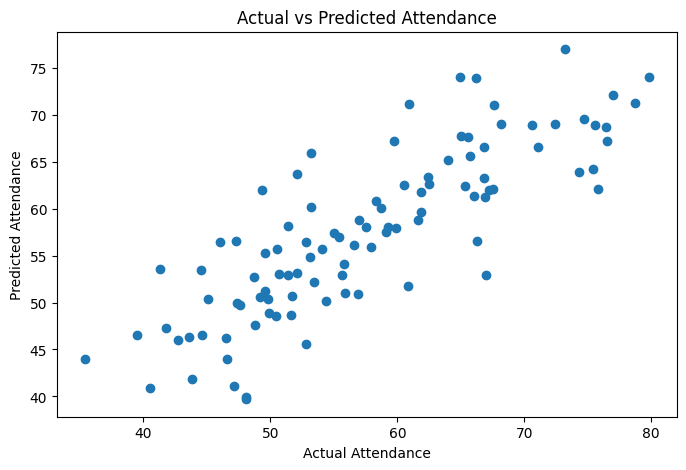

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.title("Actual vs Predicted Attendance")

plt.show()

In [ ]:
student_data = pd.DataFrame({
    "Age": [21],
    "Semester": [5],
    "Total_Classes": [80],
    "Classes_Attended": [55],
    "Previous_Month_Attendance": [68],
    "Assignment_Submission": [80],
    "Internal_Marks": [75],
    "Practical_Attendance": [70],
    "Medical_Leave": [2],
    "Extracurricular_Hours": [3],
    "Commute_Time_Min": [30]
})

In [ ]:
prediction = model.predict(student_data)

print("Predicted Attendance:",
      round(prediction[0], 2), "%")

Predicted Attendance: 59.0 %


In [ ]:
predicted_attendance = prediction[0]

if predicted_attendance < 60:
    risk = "High Risk"
elif predicted_attendance < 75:
    risk = "Medium Risk"
else:
    risk = "Low Risk"

print("Risk Level:", risk)

Risk Level: High Risk


In [ ]:
def required_classes(attended, total, target=75):
    x = 0

    while ((attended + x) / (total + x)) * 100 < target:
        x += 1

    return x

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

,0
Previous_Month_Attendance,0.600026
Classes_Attended,0.135403
Assignment_Submission,0.058325
Total_Classes,0.049431
Practical_Attendance,0.045934
Extracurricular_Hours,0.027686
Internal_Marks,0.026919
Commute_Time_Min,0.025036
Medical_Leave,0.016030
Age,0.008131


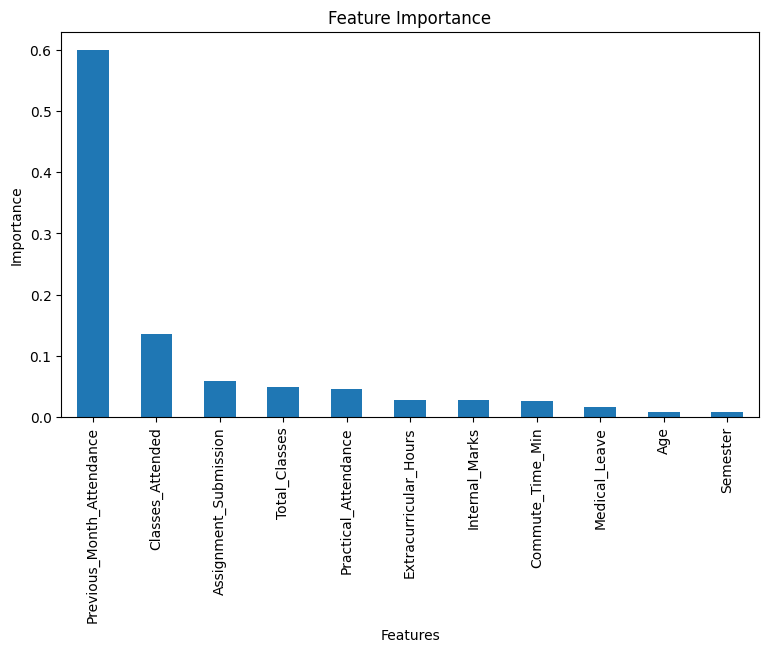

In [ ]:
importance.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [ ]:
import joblib

joblib.dump(model, "attendance_prediction_model.pkl")

['attendance_prediction_model.pkl']